In [1]:
prompt = """
You are given:
1) A target concept.
2) A list of tokens (strings).

Your task is to perform a **binary classification at the token level**.

For EACH token in the list, determine whether it **represents, refers to, or is semantically associated with** the given concept.

-------------------------------------
DEFINITION OF "BELONGING TO CONCEPT"
-------------------------------------
A token should be labeled:

- 1 → if it clearly falls under, represents, or is strongly associated with the concept
- 0 → otherwise

This includes:
- Direct matches (e.g., "red" for the concept "color")
- Variants and forms (e.g., "reddish", "greenish")
- Synonyms or closely related terms
- Named entities or instances of the concept (e.g., "John" for the concept "person")
- Pronouns if applicable (e.g., "he", "she" for "person")
- Context-independent classification ONLY (do NOT assume surrounding sentence context)

-------------------------------------
IMPORTANT RULES
-------------------------------------
- Treat each token independently (no sequence/context reasoning)
- Be inclusive but precise: include tokens that reasonably map to the concept
- Do NOT overgeneralize (e.g., "object" is not a "person")
- Ignore capitalization differences unless meaningful
- If uncertain, prefer 0 unless there is a strong semantic link
- Output must strictly reflect the input tokens (no additions, no removals)

-------------------------------------
OUTPUT FORMAT (STRICT)
-------------------------------------
Return a valid Python dictionary (JSON-compatible):

- Keys: EXACT tokens from the input list (unchanged)
- Values: 1 or 0 only

Example format:
{{
    "token1": 1,
    "token2": 0
}}

-------------------------------------
EXAMPLES
-------------------------------------
Concept: "color"
- "red" → 1
- "blue" → 1
- "table" → 0

Concept: "person"
- "John" → 1
- "she" → 1
- "teacher" → 1
- "car" → 0

-------------------------------------
NOW PERFORM THE TASK
-------------------------------------
Concept: "{concept}"
Tokens: {tokens}

Return ONLY the dictionary. No explanation, no extra text.
"""

In [ ]:
from typing import List, Dict
from pydantic import BaseModel
import instructor
from openai import OpenAI
import os 


class TokenClassification(BaseModel):
    labels: Dict[str, int]

client = instructor.from_openai(OpenAI(
    api_key=os.environ.get("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1",
))

def classify_tokens(tokens: List[str], concept: str) -> Dict[str, int]:
    formatted_prompt = prompt.format(tokens=tokens, concept=concept)

    response = client.chat.completions.create(
        model="openai/gpt-oss-20b",
        response_model=TokenClassification,
        messages=[
            {"role": "user", "content": formatted_prompt}
        ],
        temperature=0
    )

    return response.labels

In [3]:
classify_tokens(["red", "bread", "blue", "heights"], "colors")

{'blue': 1, 'bread': 0, 'heights': 0, 'red': 1}

In [1]:
from transformers import AutoProcessor

processor = AutoProcessor.from_pretrained("google/gemma-3-27b-it")

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [2]:
messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": "https://raw.githubusercontent.com/KhaledAbuQ/ML_Project/main/Lab_Test.jpg"},
            {"type": "text", "text": "Describe this image in detail."}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
)

In [10]:
import numpy as np

x = inputs["pixel_values"].numpy()
x = (x + 1) / 2       
x = x.clip(0, 1)     
x = x * 255
x = x.astype(np.uint8).reshape((x.shape[1], x.shape[2], x.shape[3]))   
x = np.transpose(x, (1, 2, 0))

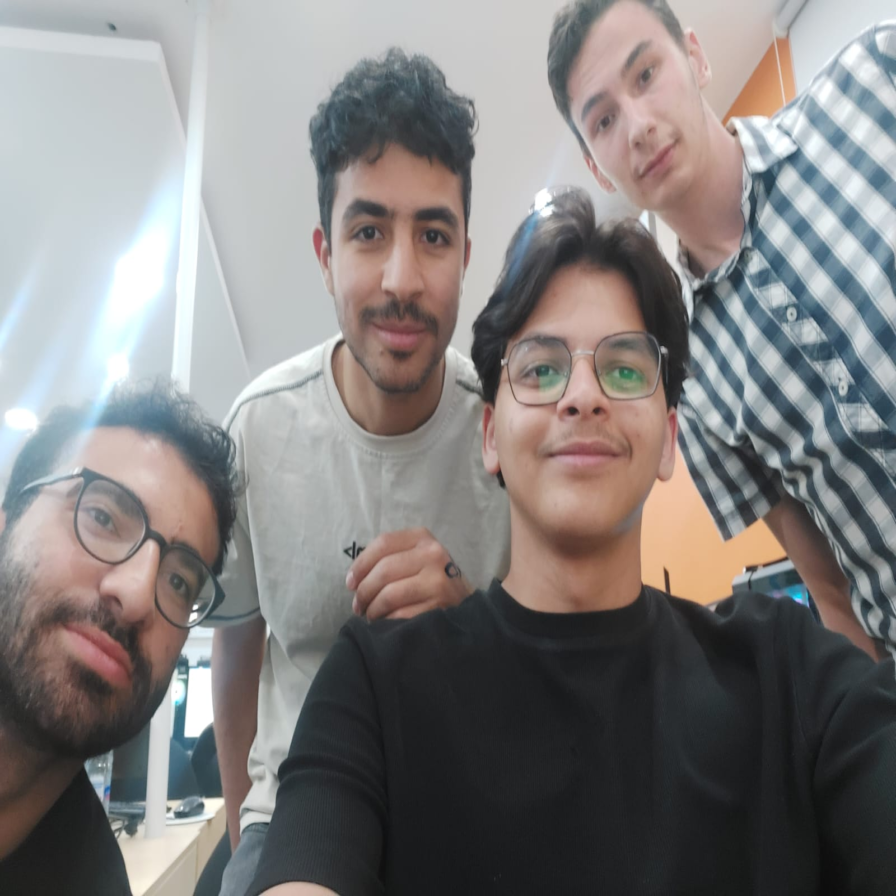

In [11]:
from PIL import Image

Image.fromarray(x)

In [56]:
import torch

end_of_image = torch.argwhere(inputs["input_ids"][0]==256000)[0][0]
end_of_turn = torch.argwhere(inputs["input_ids"][0]==107)[-2][0]

tokens_of_interest = inputs["input_ids"][0][end_of_image+1:end_of_turn-1]